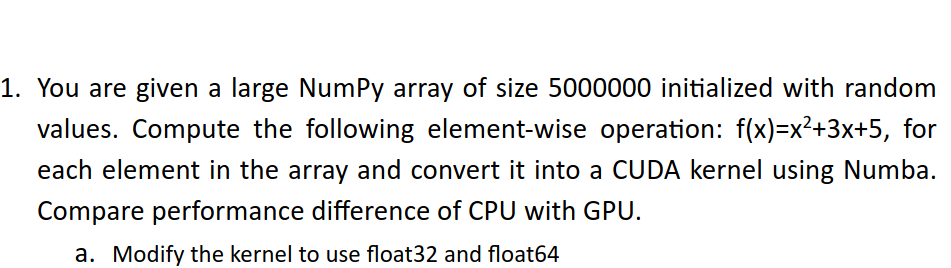

In [2]:
import numpy as np
import time
from numba import cuda, jit, vectorize, float32, float64

N = 5000000
arr_float64 = np.random.rand(N).astype(np.float64)
arr_float32 = np.random.rand(N).astype(np.float32)

def cpu_compute(x):
    return x*x + 3*x + 5

start = time.time()
cpu_result = cpu_compute(arr_float64)
cpu_time = time.time() - start

@cuda.jit
def gpu_compute_float64(x, out):
    i = cuda.grid(1)
    if i < x.size:
        out[i] = x[i]*x[i] + 3*x[i] + 5

@cuda.jit
def gpu_compute_float32(x, out):
    i = cuda.grid(1)
    if i < x.size:
        out[i] = x[i]*x[i] + 3*x[i] + 5

threadsperblock = 256
blockspergrid = (N + threadsperblock - 1) // threadsperblock

d_x64 = cuda.to_device(arr_float64)
d_out64 = cuda.device_array_like(arr_float64)

start = time.time()
gpu_compute_float64[blockspergrid, threadsperblock](d_x64, d_out64)
cuda.synchronize()
gpu_time64 = time.time() - start

d_x32 = cuda.to_device(arr_float32)
d_out32 = cuda.device_array_like(arr_float32)

start = time.time()
gpu_compute_float32[blockspergrid, threadsperblock](d_x32, d_out32)
cuda.synchronize()
gpu_time32 = time.time() - start

print("CPU Time:", cpu_time)
print("GPU float64 Time:", gpu_time64)
print("GPU float32 Time:", gpu_time32)

CPU Time: 0.035495758056640625
GPU float64 Time: 1.9468257427215576
GPU float32 Time: 0.06650280952453613


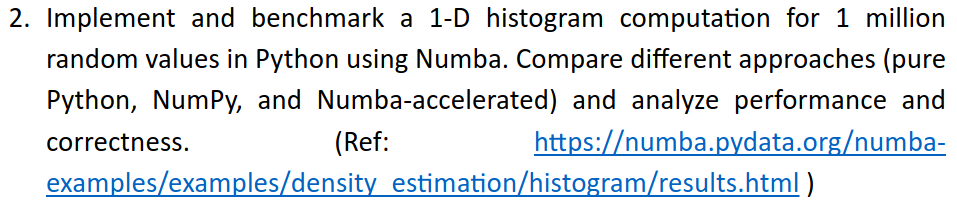

In [3]:

import numpy as np
from numba import njit
import time

data = np.random.rand(1000000)
bins = 50

def python_hist(data, bins):
    hist = [0]*bins
    for x in data:
        idx = min(int(x*bins), bins-1)
        hist[idx] += 1
    return hist

@njit
def numba_hist(data, bins):
    hist = np.zeros(bins)
    for x in data:
        idx = min(int(x*bins), bins-1)
        hist[idx] += 1
    return hist

start = time.time()
py_hist = python_hist(data, bins)
py_time = time.time() - start

start = time.time()
np_hist, _ = np.histogram(data, bins=bins, range=(0,1))
np_time = time.time() - start

numba_hist(data, bins)
start = time.time()
nb_hist = numba_hist(data, bins)
nb_time = time.time() - start

print("Python Time:", py_time)
print("NumPy Time:", np_time)
print("Numba Time:", nb_time)


Python Time: 0.38357090950012207
NumPy Time: 0.02323627471923828
Numba Time: 0.0016903877258300781


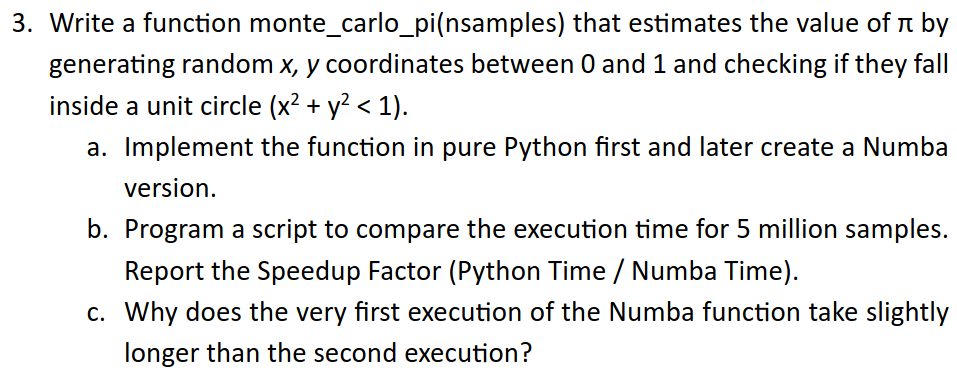

In [4]:

import random
from numba import njit
import time

def monte_carlo_pi_py(nsamples):
    inside = 0
    for _ in range(nsamples):
        x = random.random()
        y = random.random()
        if x*x + y*y < 1:
            inside += 1
    return 4 * inside / nsamples

@njit
def monte_carlo_pi_nb(nsamples):
    inside = 0
    for i in range(nsamples):
        x = np.random.rand()
        y = np.random.rand()
        if x*x + y*y < 1:
            inside += 1
    return 4 * inside / nsamples

nsamples = 5000000

start = time.time()
pi_py = monte_carlo_pi_py(nsamples)
py_time = time.time() - start

monte_carlo_pi_nb(nsamples)
start = time.time()
pi_nb = monte_carlo_pi_nb(nsamples)
nb_time = time.time() - start

print("Python Time:", py_time)
print("Numba Time:", nb_time)
print("Speedup:", py_time/nb_time)


Python Time: 0.8949947357177734
Numba Time: 0.05742621421813965
Speedup: 15.585125154133262


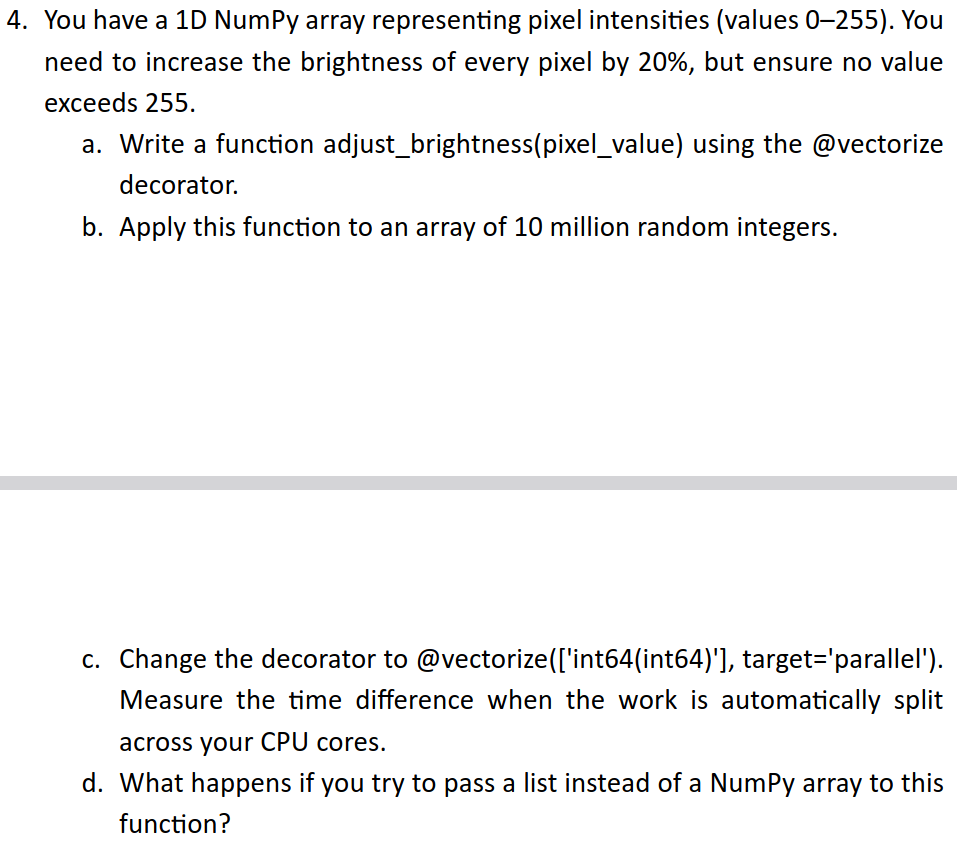

In [5]:

from numba import vectorize

@vectorize(['int64(int64)'])
def adjust_brightness(pixel):
    val = int(pixel * 1.2)
    return 255 if val > 255 else val

pixels = np.random.randint(0, 256, 10000000)
start = time.time()
bright = adjust_brightness(pixels)
time_seq = time.time() - start

@vectorize(['int64(int64)'], target='parallel')
def adjust_brightness_parallel(pixel):
    val = int(pixel * 1.2)
    return 255 if val > 255 else val

start = time.time()
bright_parallel = adjust_brightness_parallel(pixels)
time_par = time.time() - start

print("Sequential Time:", time_seq)
print("Parallel Time:", time_par)


Sequential Time: 0.03137087821960449
Parallel Time: 0.024768590927124023


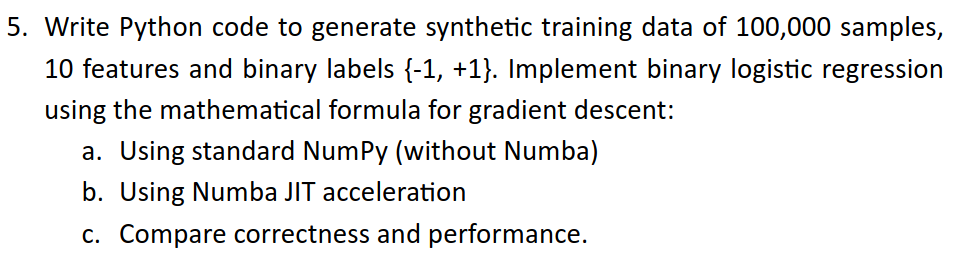

In [6]:

import numpy as np
from numba import njit
import time

np.random.seed(0)
X = np.random.randn(100000, 10)
y = np.random.choice([-1,1], 100000)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_numpy(X, y, lr=0.01, epochs=10):
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        z = X @ w
        grad = -(y * (1 - sigmoid(y*z))) @ X / len(y)
        w -= lr * grad
    return w

@njit
def logistic_numba(X, y, lr=0.01, epochs=10):
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        z = X @ w
        sig = 1 / (1 + np.exp(-y*z))
        grad = -(y * (1 - sig)) @ X / len(y)
        w -= lr * grad
    return w

start = time.time()
w_np = logistic_numpy(X, y)
time_np = time.time() - start

logistic_numba(X, y)
start = time.time()
w_nb = logistic_numba(X, y)
time_nb = time.time() - start

print("NumPy Time:", time_np)
print("Numba Time:", time_nb)
print("Weights difference norm:", np.linalg.norm(w_np - w_nb))


NumPy Time: 0.06845355033874512
Numba Time: 0.05749154090881348
Weights difference norm: 6.578561967820426e-20


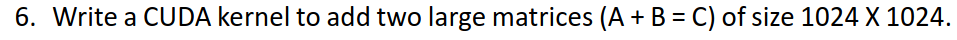

In [7]:
@cuda.jit
def mat_add(A, B, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        C[row, col] = A[row, col] + B[row, col]

A = np.random.rand(1024,1024)
B = np.random.rand(1024,1024)
C = np.zeros_like(A)

d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.to_device(C)

threadsperblock = (16,16)
blockspergrid_x = (A.shape[0] + 15)//16
blockspergrid_y = (A.shape[1] + 15)//16

mat_add[(blockspergrid_x, blockspergrid_y), threadsperblock](d_A, d_B, d_C)
cuda.synchronize()

C = d_C.copy_to_host()

print("Matrix addition completed.")
print("Result Matrix (first 5x5 block):")
print(C[:5, :5])

Matrix addition completed.
Result Matrix (first 5x5 block):
[[1.25486551 1.03878586 0.8131633  0.64286376 1.44197122]
 [1.40171971 1.60205925 0.36045078 0.65836577 0.66056118]
 [1.50428964 0.45812164 0.49467662 1.87062981 0.98306839]
 [0.57861365 1.34730462 1.19932524 1.60680457 1.11921349]
 [0.20089875 1.8090241  1.29954201 0.55780446 1.34289337]]
